In [1]:
import os
import tensorflow as tf
import pandas as pd
import sys
import matplotlib.pyplot as plt
from itertools import permutations, combinations
from matplotlib import rcParams, cycler
sys.path.append(os.path.join('c:\\', *os.getcwd().split('\\')[1:-1]))
from sgcc8 import *

In [2]:
param_bounds = {
    "fts": [0, 175],
    "t": [40, 125],
    "ampc": [0.01, 0.1],
    'ampm': [0,3],
    "ampg": [0.1, 4],
    "ampw": [0.01, 0.08],
    "d": [10, 40],
    "inh_d": [0, 40],
    "inh_w": [0, 3],
}

perm_choices = np.array(list(permutations(permutations(np.arange(3)), 2)))
random_index = np.random.randint(0,29,size=(10,7))
random_perm = perm_choices[random_index]
P0 = tf.one_hot(
    random_perm,
    3,
    axis=-1,
)
P0 = tf.transpose(P0, (0,1,2,4,3))
P0 = tf.where(P0 == 1.0, 
                  tf.ones_like(P0) * 10.0,   # large positive
                  tf.ones_like(P0) * -10.0)  # large negative

In [3]:
model = SGCCircuit(bounds=param_bounds, identify=True, enforce_permutation='default')
model.initialize_random_parameters(2,3,10)
model.update_transform()

Model initialized with default permutation
Model initialized with default permutation


Text(0.525, 0.975, 'Raw dLGN parameters')

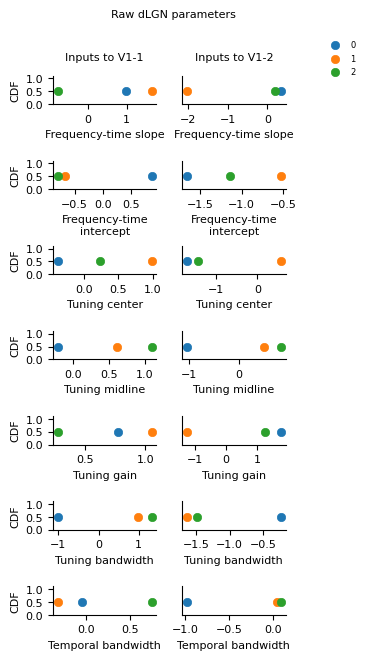

In [4]:
cmap = plt.get_cmap('tab10') 
rcParams['axes.prop_cycle'] = cycler(color=cmap(np.linspace(0, 1, 10)))
fig, ax = plt.subplots(7,2, figsize = (3,7))
fontsize = 8
linewidth = 0.5
param_labels = [
    'Frequency-time slope',
    'Frequency-time\nintercept',
    'Tuning center',
    'Tuning midline',
    'Tuning gain',
    'Tuning bandwidth',
    'Temporal bandwidth'
]

neuron_labels = [f'dLGN_{i+1}' for i in range(3)]


for row in range(7):
    ymax = []
    for i in range(3):
        for u in range(2):
            ax[row, u].scatter(model.dlgn_raw[0, u, i, row, 0, 0], [0.5], label = i, linewidth = linewidth)
            ax[row, u].set_xlabel(param_labels[row], fontsize = fontsize)
            ax[row, u].tick_params(labelsize = fontsize)

    ax[row, 0].set_ylabel("CDF", fontsize = fontsize)
    for u in range(2):
        ax[row, u].set_ylim(0, 1.1)
        ax[row, 1].set_yticks([])
        ax[row, 0].set_yticks(np.arange(0, 1.5, 0.5))
        ax[row, u].spines['top'].set_visible(False)
        ax[row, u].spines['right'].set_visible(False)

fig.subplots_adjust(hspace = 2, wspace=0.25)
plt.tick_params(labelsize = 8)
ax[0,1].legend(fontsize = 6, bbox_to_anchor = (1.75,2.5), frameon = False)
ax[0,0].set_title("Inputs to V1-1", fontsize = fontsize, y = 1.25)
ax[0,1].set_title("Inputs to V1-2", fontsize = fontsize, y = 1.25)
plt.suptitle("Raw dLGN parameters", fontsize = fontsize, x = 0.525, y = 0.975)


Model initialized with default permutation
Model initialized with default permutation
Model initialized with default permutation
Model initialized with default permutation
Model initialized with default permutation
Model initialized with default permutation
Model initialized with default permutation
Model initialized with default permutation
Model initialized with default permutation
Model initialized with default permutation
Model initialized with default permutation
Model initialized with default permutation
Model initialized with default permutation
Model initialized with default permutation
Model initialized with default permutation
Model initialized with default permutation
Model initialized with default permutation
Model initialized with default permutation
Model initialized with default permutation
Model initialized with default permutation
Model initialized with default permutation
Model initialized with default permutation
Model initialized with default permutation
Model initi

Text(0.525, 0.975, 'Normalized with permutation + identifiability')

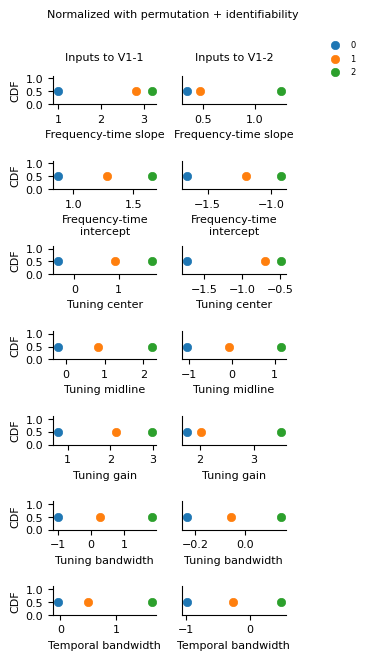

In [5]:
cmap = plt.get_cmap('tab10') 
rcParams['axes.prop_cycle'] = cycler(color=cmap(np.linspace(0, 1, 10)))
fig, ax = plt.subplots(7,2, figsize = (3,7))
fontsize = 8
linewidth = 0.5
param_labels = [
    'Frequency-time slope',
    'Frequency-time\nintercept',
    'Tuning center',
    'Tuning midline',
    'Tuning gain',
    'Tuning bandwidth',
    'Temporal bandwidth'
]

neuron_labels = [f'dLGN_{i+1}' for i in range(3)]


for row in range(7):
    ymax = []
    for i in range(3):
        for u in range(2):
            ax[row, u].scatter(model.dlgn_scaled[0, u, i, row, 0, 0], [0.5], label = i, linewidth = linewidth)
            ax[row, u].set_xlabel(param_labels[row], fontsize = fontsize)
            ax[row, u].tick_params(labelsize = fontsize)

    ax[row, 0].set_ylabel("CDF", fontsize = fontsize)
    for u in range(2):
        ax[row, u].set_ylim(0, 1.1)
        ax[row, 1].set_yticks([])
        ax[row, 0].set_yticks(np.arange(0, 1.5, 0.5))
        ax[row, u].spines['top'].set_visible(False)
        ax[row, u].spines['right'].set_visible(False)

fig.subplots_adjust(hspace = 2, wspace=0.25)
plt.tick_params(labelsize = 8)
ax[0,1].legend(fontsize = 6, bbox_to_anchor = (1.75,2.5), frameon = False)
ax[0,0].set_title("Inputs to V1-1", fontsize = fontsize, y = 1.25)
ax[0,1].set_title("Inputs to V1-2", fontsize = fontsize, y = 1.25)
plt.suptitle("Normalized with permutation + identifiability", fontsize = fontsize, x = 0.525, y = 0.975)


In [6]:
## Get the inverse permutation matrix 
params = model.dlgn_scaled[:,:,:,:,0,0]
op_perm = np.argsort(np.argsort(params, axis=2), axis=2).transpose(0,3,1,2)
P = tf.one_hot(
    op_perm,
    3,
    axis=-1,
)

## Apply the inverse permutation
D = tf.transpose(params, (0,3,1,2))[:,:,:,None,:]
D = tf.squeeze(tf.matmul(D, P))
D = tf.transpose(D, (0,2,3,1))[:,:,:,:,None,None]

Model initialized with default permutation


Text(0.525, 0.975, 'Normalized with original ordering retrieved')

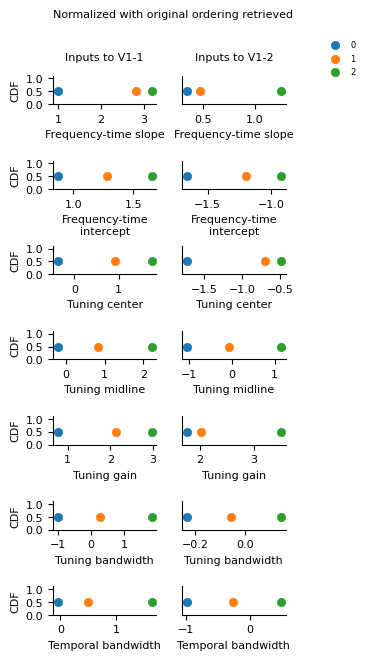

In [7]:
cmap = plt.get_cmap('tab10') 
rcParams['axes.prop_cycle'] = cycler(color=cmap(np.linspace(0, 1, 10)))
fig, ax = plt.subplots(7,2, figsize = (3,7))
fontsize = 8
linewidth = 0.5
param_labels = [
    'Frequency-time slope',
    'Frequency-time\nintercept',
    'Tuning center',
    'Tuning midline',
    'Tuning gain',
    'Tuning bandwidth',
    'Temporal bandwidth'
]

neuron_labels = [f'dLGN_{i+1}' for i in range(3)]


for row in range(7):
    ymax = []
    for i in range(3):
        for u in range(2):
            ax[row, u].scatter(D[0, u, i, row, 0, 0], [0.5], label = i, linewidth = linewidth)
            ax[row, u].set_xlabel(param_labels[row], fontsize = fontsize)
            ax[row, u].tick_params(labelsize = fontsize)

    ax[row, 0].set_ylabel("CDF", fontsize = fontsize)
    for u in range(2):
        ax[row, u].set_ylim(0, 1.1)
        ax[row, 1].set_yticks([])
        ax[row, 0].set_yticks(np.arange(0, 1.5, 0.5))
        ax[row, u].spines['top'].set_visible(False)
        ax[row, u].spines['right'].set_visible(False)

fig.subplots_adjust(hspace = 2, wspace=0.25)
plt.tick_params(labelsize = 8)
ax[0,1].legend(fontsize = 6, bbox_to_anchor = (1.75,2.5), frameon = False)
ax[0,0].set_title("Inputs to V1-1", fontsize = fontsize, y = 1.25)
ax[0,1].set_title("Inputs to V1-2", fontsize = fontsize, y = 1.25)
plt.suptitle("Normalized with original ordering retrieved", fontsize = fontsize, x = 0.525, y = 0.975)


In [8]:
C = model.inverse_dlgn_property(D)

Text(0.525, 0.975, 'Raw retrieved')

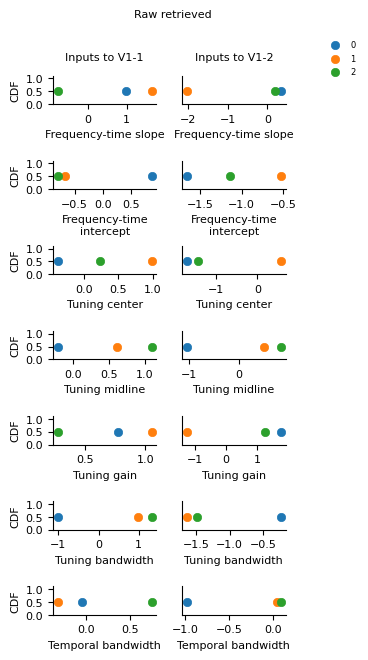

In [9]:
cmap = plt.get_cmap('tab10') 
rcParams['axes.prop_cycle'] = cycler(color=cmap(np.linspace(0, 1, 10)))
fig, ax = plt.subplots(7,2, figsize = (3,7))
fontsize = 8
linewidth = 0.5
param_labels = [
    'Frequency-time slope',
    'Frequency-time\nintercept',
    'Tuning center',
    'Tuning midline',
    'Tuning gain',
    'Tuning bandwidth',
    'Temporal bandwidth'
]

neuron_labels = [f'dLGN_{i+1}' for i in range(3)]


for row in range(7):
    ymax = []
    for i in range(3):
        for u in range(2):
            ax[row, u].scatter(C[0, u, i, row, 0, 0], [0.5], label = i, linewidth = linewidth)
            ax[row, u].set_xlabel(param_labels[row], fontsize = fontsize)
            ax[row, u].tick_params(labelsize = fontsize)

    ax[row, 0].set_ylabel("CDF", fontsize = fontsize)
    for u in range(2):
        ax[row, u].set_ylim(0, 1.1)
        ax[row, 1].set_yticks([])
        ax[row, 0].set_yticks(np.arange(0, 1.5, 0.5))
        ax[row, u].spines['top'].set_visible(False)
        ax[row, u].spines['right'].set_visible(False)

fig.subplots_adjust(hspace = 2, wspace=0.25)
plt.tick_params(labelsize = 8)
ax[0,1].legend(fontsize = 6, bbox_to_anchor = (1.75,2.5), frameon = False)
ax[0,0].set_title("Inputs to V1-1", fontsize = fontsize, y = 1.25)
ax[0,1].set_title("Inputs to V1-2", fontsize = fontsize, y = 1.25)
plt.suptitle("Raw retrieved", fontsize = fontsize, x = 0.525, y = 0.975)


In [10]:
from sgcc9 import *
model2 = SGCCircuit(bounds=param_bounds)
E = model2.inverse_dlgn_property(model.dlgn_scaled)

Model initialized with default permutation


Text(0.525, 0.975, 'Raw retrieved with inverse_dlgn_property')

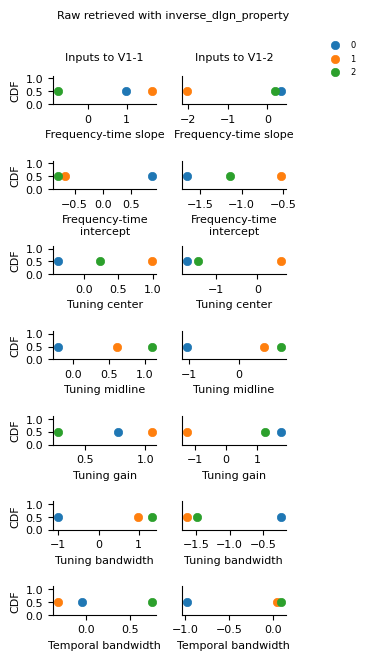

In [11]:
cmap = plt.get_cmap('tab10') 
rcParams['axes.prop_cycle'] = cycler(color=cmap(np.linspace(0, 1, 10)))
fig, ax = plt.subplots(7,2, figsize = (3,7))
fontsize = 8
linewidth = 0.5
param_labels = [
    'Frequency-time slope',
    'Frequency-time\nintercept',
    'Tuning center',
    'Tuning midline',
    'Tuning gain',
    'Tuning bandwidth',
    'Temporal bandwidth'
]

neuron_labels = [f'dLGN_{i+1}' for i in range(3)]


for row in range(7):
    ymax = []
    for i in range(3):
        for u in range(2):
            ax[row, u].scatter(E[0, u, i, row, 0, 0], [0.5], label = i, linewidth = linewidth)
            ax[row, u].set_xlabel(param_labels[row], fontsize = fontsize)
            ax[row, u].tick_params(labelsize = fontsize)

    ax[row, 0].set_ylabel("CDF", fontsize = fontsize)
    for u in range(2):
        ax[row, u].set_ylim(0, 1.1)
        ax[row, 1].set_yticks([])
        ax[row, 0].set_yticks(np.arange(0, 1.5, 0.5))
        ax[row, u].spines['top'].set_visible(False)
        ax[row, u].spines['right'].set_visible(False)

fig.subplots_adjust(hspace = 2, wspace=0.25)
plt.tick_params(labelsize = 8)
ax[0,1].legend(fontsize = 6, bbox_to_anchor = (1.75,2.5), frameon = False)
ax[0,0].set_title("Inputs to V1-1", fontsize = fontsize, y = 1.25)
ax[0,1].set_title("Inputs to V1-2", fontsize = fontsize, y = 1.25)
plt.suptitle("Raw retrieved with inverse_dlgn_property", fontsize = fontsize, x = 0.525, y = 0.975)
